# 03. Supervised Segmentation 
The goal of this stage is to **identify which features are most informative with respect to the churn outcome**, using supervised segmentation techniques.

Rather than training a full predictive model, this step focuses on understanding how individual features partition the customer population into groups with different churn behavior.

This stage answers the question:

> Which customer attributes reduce uncertainty about churn the most?

## 3.1. Environment setup

In [1]:
import numpy as np
import pandas as pd
from math import log2

import matplotlib.pyplot as plt
import seaborn as sns

## 3.2. Load prepared training data

In [13]:
X_train = pd.read_csv("../data/X_train.csv")
y_train = pd.read_csv("../data/y_train.csv")["churn"]

### 3.2.1. Quick sanity checks

In [14]:
print(X_train.shape)
print(y_train.shape)

X_train.head(), y_train.head()

(4800, 17)
(4800,)


(   customer_id   plan region    industry  tenure_months  team_size  \
 0         2243  Basic   APAC  Healthcare             31          2   
 1          264  Basic     EU  E-commerce              1          7   
 2         1801    Pro    NaN        SaaS             17          5   
 3         5321  Basic    NaN  E-commerce             39          3   
 4         2076    Pro     EU        SaaS              5          1   
 
    monthly_price  logins_per_week  campaigns_per_month  automation_used  \
 0           9.93             4.17                    6                0   
 1          26.03             5.50                    5                0   
 2          54.52             3.41                    7                1   
 3          16.02             2.56                    5                1   
 4          53.85             1.87                    4                1   
 
    onboarding_completed  integrations_connected  support_tickets_90d  \
 0                     0                 

## 3.3. Base entropy
We first compute the entropy of the target variable (`churn`) on the training set.

This value represents the baseline level of uncertainty about churn **before** considering any features.
All subsequent information gain calculations measure how much individual features reduce this baseline uncertainty.

In [15]:
def entropy(y):
    probs = y.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))

base_entropy = entropy(y_train)
base_entropy

np.float64(0.922811132172962)

## 3.4. Segmentation rules
Supervised segmentation is performed to assess feature informativeness prior to any preprocessing or model fitting.

The following rules are applied:

- No imputation is performed; missing values are treated as an explicit category.
- No scaling or normalization is applied, as entropy-based measures depend only on class proportions.
- Categorical features are evaluated in their original form (no one-hot encoding).
- Binary features are segmented directly into two groups (0 / 1).
- Numeric features are discretized using simple, interpretable splits for entropy calculation only.
- All computations are based on training data exclusively.

These choices ensure that entropy and information gain reflect the raw informational structure of the data.

## 3.5. Entropy & Information Gain per feature
For each feature, we compute the entropy of churn across its induced segments and measure the corresponding information gain.

Segment definitions depend on feature type:

- Binary and low-cardinality categorical features are evaluated using their natural value splits.
- Continuous and high-cardinality features require controlled segmentation (binning) to avoid artificially inflated information gain.

This ensures that information gain reflects true discriminatory power rather than over-fragmentation.

### 3.5.1. Helper: Entropy (binary target)
We use Shannon entropy to quantify uncertainty in the binary churn label (0/1).  
This helper is used to compute segment entropies and weighted post-split entropy for Information Gain.

In [27]:
def entropy_binary(y) -> float:
    """
    Shannon entropy for a binary target (0/1).
    Returns value in [0, 1].
    """
    y = pd.Series(y).dropna()

    if len(y) == 0:
        return np.nan

    # Ensure numeric 0/1
    y = y.astype(int)

    p1 = (y == 1).mean()
    p0 = 1 - p1

    entropy = 0.0
    for p in (p0, p1):
        if p > 0:
            entropy -= p * np.log2(p)

    return float(entropy)

In [28]:
print("Entropy([0,0,0,0]) =", entropy_binary([0,0,0,0]))  
print("Entropy([0,1])     =", entropy_binary([0,1]))      
print("Entropy(y_train)   =", entropy_binary(y_train))   

Entropy([0,0,0,0]) = 0.0
Entropy([0,1])     = 1.0
Entropy(y_train)   = 0.922811132172962


In [58]:
def ig_for_manual_segments(
    X: pd.DataFrame,
    y: pd.Series,
    feature: str,
    bins: list,
    labels: list,
    base_entropy: float
) -> tuple[pd.DataFrame, dict]:
    """
    Compute segment-level stats, weighted entropy and IG
    for manually defined numeric thresholds.
    """

    binned = pd.cut(X[feature], bins=bins, labels=labels)

    tmp = pd.DataFrame({
        "segment": binned,
        "churn": y
    })

    N = len(tmp)

    seg_rows = []
    for seg_val, grp in tmp.groupby("segment", dropna=False, observed=True):
        seg_rows.append({
            "feature": feature,
            "segment": str(seg_val),
            "n": len(grp),
            "weight": len(grp) / N,
            "entropy": entropy_binary(grp["churn"]),
            "churn_rate": grp["churn"].mean(),
        })

    seg_df = pd.DataFrame(seg_rows).sort_values("n", ascending=False)

    weighted_entropy = (seg_df["weight"] * seg_df["entropy"]).sum()
    information_gain = base_entropy - weighted_entropy

    summary = {
        "feature": feature,
        "segmentation": "manual",
        "base_entropy": base_entropy,
        "weighted_entropy": weighted_entropy,
        "information_gain": information_gain,
        "n_segments": seg_df.shape[0],
    }

    return seg_df, summary

### 3.5.2. Natural-split Information Gain (binary & low-cardinality categorical)
**Key observations from natural-split Information Gain analysis:**
- No binary or low-cardinality categorical feature provides strong standalone discriminatory power for churn.
- `onboarding_completed` is the most informative simple feature, but still leaves substantial uncertainty.
- Plan, region, and industry create highly mixed segments with similar churn rates.
- These results indicate that churn is driven by combinations of behavioral and lifecycle factors rather than single categorical attributes.

This motivates the use of controlled segmentation for numeric features and multi-feature modeling in subsequent stages.

In [29]:
def ig_natural_split(X: pd.DataFrame, y: pd.Series, feature: str, base_entropy: float) -> dict:
    """
    Information Gain for a feature using its natural value splits (including NaN as a segment).
    Returns both IG summary and the segment table.
    """
    tmp = pd.DataFrame({feature: X[feature], "churn": y}).copy()
    N = len(tmp)

    seg_rows = []
    for val, grp in tmp.groupby(feature, dropna=False):
        seg_rows.append({
            "feature": feature,
            "value": val,
            "n": len(grp),
            "weight": len(grp) / N,
            "entropy": entropy_binary(grp["churn"]),
            "churn_rate": grp["churn"].mean(),
        })

    seg_df = (
        pd.DataFrame(seg_rows)
        .sort_values("n", ascending=False)
        .reset_index(drop=True)
    )

    weighted_entropy = float((seg_df["weight"] * seg_df["entropy"]).sum())
    ig = float(base_entropy - weighted_entropy)

    summary = {
        "feature": feature,
        "base_entropy": float(base_entropy),
        "weighted_entropy": weighted_entropy,
        "information_gain": ig,
        "n_segments": int(seg_df.shape[0]),
    }

    return {"summary": summary, "segments": seg_df}

In [30]:
simple_features = [
    "plan",
    "region",
    "industry",
    "automation_used",
    "onboarding_completed",
    "failed_payments_6m",
    "discount_used",
]

results = []
segments_by_feature = {}

for f in simple_features:
    out = ig_natural_split(X_train, y_train, f, base_entropy)
    results.append(out["summary"])
    segments_by_feature[f] = out["segments"]

ig_simple_df = (
    pd.DataFrame(results)
    .sort_values("information_gain", ascending=False)
    .reset_index(drop=True)
)

ig_simple_df

,feature,base_entropy,weighted_entropy,information_gain,n_segments
0,onboarding_completed,0.922811,0.900621,0.022190,2
1,failed_payments_6m,0.922811,0.913687,0.009125,3
2,plan,0.922811,0.917848,0.004963,4
3,automation_used,0.922811,0.918490,0.004321,2
4,discount_used,0.922811,0.921569,0.001242,2
5,industry,0.922811,0.922089,0.000722,6
6,region,0.922811,0.922624,0.000187,4


In [31]:
segments_by_feature["plan"]

,feature,value,n,weight,entropy,churn_rate
0,plan,Basic,2174,0.452917,0.957022,0.378565
1,plan,Pro,1429,0.297708,0.870154,0.291113
2,plan,Business,876,0.182500,0.913662,0.328767
3,plan,Enterprise,321,0.066875,0.876284,0.295950


### 3.5.3. Controlled segmentation (numeric features)
For numeric and high-cardinality features, information gain is computed using controlled segmentation (binning).
We use quantile-based bins (quintiles) to prevent over-fragmentation and make IG comparable across features.
Missing values are kept as a separate segment.
The following numeric features are analyzed using controlled segmentation:

- `monthly_price`
- `tenure_months`
- `logins_per_week`
- `campaigns_per_month`
- `avg_response_hours`
- `nps`
- `team_size`
- `integrations_connected`
- `support_tickets_90d`

For each feature, we compute:
- segment-level entropy of churn
- weighted post-split entropy
- information gain relative to the base entropy
- number of bins and missing values

In [32]:
numeric_features = [
    "monthly_price",
    "tenure_months",
    "logins_per_week",
    "campaigns_per_month",
    "avg_response_hours",
    "nps",
    "team_size",
    "integrations_connected",
    "support_tickets_90d",
]

missing_cols = [c for c in numeric_features if c not in X_train.columns]
print("Missing columns in X_train:", missing_cols)

print("Numeric feature count:", len(numeric_features))

Missing columns in X_train: []
Numeric feature count: 9


In [34]:
def make_qcut_bins(s: pd.Series, q: int = 5) -> pd.Series:
    """
    Quantile binning with q bins. Keeps NaN as NaN (will be handled as a separate segment later).
    Returns a categorical Series with Interval bins.
    """
    s_non_null = s.dropna()
    if s_non_null.nunique() < 2:
        return pd.Series([pd.NA] * len(s), index=s.index, dtype="category")
    return pd.qcut(s, q=q, duplicates="drop")

In [37]:
def ig_for_binned_feature(
    X: pd.DataFrame,
    y: pd.Series,
    feature: str,
    base_entropy: float,
    q: int = 5
) -> tuple[dict, pd.DataFrame]:
    """
    Compute Information Gain for a numeric feature using quantile-based binning.

    Returns:
        summary: dict with base_entropy, weighted_entropy, information_gain,
                 number of segments, bins, and missing values
        seg_df: DataFrame with per-segment statistics
    """

    # 1) Apply quantile-based binning (NaNs preserved)
    binned = make_qcut_bins(X[feature], q=q)

    # 2) Build temporary DataFrame with bins and target
    tmp = pd.DataFrame({
        "bin": binned,
        "churn": y
    })

    N = len(tmp)

    # 3) Compute segment-level statistics
    seg_rows = []
    for bin_val, grp in tmp.groupby("bin", dropna=False, observed=True):
        seg_rows.append({
            "feature": feature,
            "segment": str(bin_val),          # interval or NaN
            "n": len(grp),
            "weight": len(grp) / N,
            "entropy": entropy_binary(grp["churn"]),
            "churn_rate": grp["churn"].mean(),
        })

    seg_df = (
        pd.DataFrame(seg_rows)
        .sort_values("n", ascending=False)
        .reset_index(drop=True)
    )

    # 4) Compute weighted post-split entropy and information gain
    weighted_entropy = float((seg_df["weight"] * seg_df["entropy"]).sum())
    information_gain = float(base_entropy - weighted_entropy)

    # 5) Metadata and sanity checks
    n_missing = int(tmp["bin"].isna().sum())
    n_bins = int(pd.Series(binned).dropna().nunique())
    n_segments = int(seg_df.shape[0])  # bins + missing segment (if present)

    summary = {
        "feature": feature,
        "base_entropy": base_entropy,
        "weighted_entropy": weighted_entropy,
        "information_gain": information_gain,
        "n_segments": n_segments,
        "n_bins": n_bins,
        "n_missing": n_missing,
    }

    return summary, seg_df

#### 
The table below reports Information Gain for numeric features under uniform quantile-based segmentation (q = 5). This setup serves as a **baseline** for evaluating numeric features under controlled and comparable conditions, rather than as a final segmentation strategy.

In [38]:
binned_results = []
segments_binned_by_feature = {}

for f in numeric_features:
    summary, seg_df = ig_for_binned_feature(
        X=X_train,
        y=y_train,
        feature=f,
        base_entropy=base_entropy,
        q=5
    )
    binned_results.append(summary)
    segments_binned_by_feature[f] = seg_df

ig_binned_df = (
    pd.DataFrame(binned_results)
    .sort_values("information_gain", ascending=False)
    .reset_index(drop=True)
)

ig_binned_df

,feature,base_entropy,weighted_entropy,information_gain,n_segments,n_bins,n_missing
0,tenure_months,0.922811,0.860666,0.062145,5,5,0
1,logins_per_week,0.922811,0.917862,0.004949,5,5,0
2,monthly_price,0.922811,0.918042,0.004769,6,5,111
3,nps,0.922811,0.918294,0.004517,6,5,1187
4,integrations_connected,0.922811,0.920232,0.002580,3,3,0
5,avg_response_hours,0.922811,0.920453,0.002358,6,5,1460
6,support_tickets_90d,0.922811,0.920697,0.002114,3,3,0
7,campaigns_per_month,0.922811,0.921702,0.001109,5,5,0
8,team_size,0.922811,0.922792,0.000019,5,5,0


In [39]:
ig_binned_df[["feature", "n_bins", "n_missing", "information_gain"]]

,feature,n_bins,n_missing,information_gain
0,tenure_months,5,0,0.062145
1,logins_per_week,5,0,0.004949
2,monthly_price,5,111,0.004769
3,nps,5,1187,0.004517
4,integrations_connected,3,0,0.002580
5,avg_response_hours,5,1460,0.002358
6,support_tickets_90d,3,0,0.002114
7,campaigns_per_month,5,0,0.001109
8,team_size,5,0,0.000019


In [40]:
top_feature = ig_binned_df.loc[0, "feature"]
print("Top binned feature:", top_feature)

segments_binned_by_feature[top_feature]

Top binned feature: tenure_months


,feature,segment,n,weight,entropy,churn_rate
0,tenure_months,"(0.999, 10.0]",999,0.208125,0.997650,0.528529
1,tenure_months,"(10.0, 20.0]",986,0.205417,0.989289,0.439148
2,tenure_months,"(20.0, 30.0]",965,0.201042,0.902341,0.318135
3,tenure_months,"(30.0, 39.0]",936,0.195000,0.781201,0.231838
4,tenure_months,"(39.0, 48.0]",914,0.190417,0.609566,0.149891


#### 3.5.3.1. Interpretation
Under uniform quantile-based segmentation, most numeric features exhibit limited information gain, with relatively high entropy persisting across bins.

This suggests that automatic quantile splits do not align well with meaningful churn thresholds for several features. While variables such as `tenure_months` show stronger signal even under this constraint, others require more tailored segmentation to reveal their discriminatory power.

Consequently, quantile-based binning is treated as a baseline rather than a final strategy. In the next step, we perform feature-specific manual segmentation to identify more informative thresholds.

### 3.5.4. Feature-specific threshold exploration: monthly_price
The distribution of monthly_price is right-skewed, with a long high-end tail and visible pricing clusters.
Initial quantile-based binning and multi-tier segmentation did not produce substantial entropy reduction.

After exploratory analysis, a binary split at 40 was selected as the most stable and interpretable threshold:
- lower-priced plans ≤ 40 
- higher-priced plans > 40 

This split provides a clearer separation in churn behavior while preserving sufficient sample size in each segment.
The resulting information gain is higher and more robust than multi-bin alternatives, which tended to fragment the data without materially reducing uncertainty.

In [79]:
X_train["monthly_price"].describe()

count    4689.000000
mean       53.549891
std        52.146371
min         9.000000
25%        19.740000
50%        39.890000
75%        61.280000
max       273.880000
Name: monthly_price, dtype: float64

In [80]:
X_train["monthly_price"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01      9.0000
0.05      9.0000
0.10     12.6260
0.25     19.7400
0.50     39.8900
0.75     61.2800
0.90    103.1600
0.95    114.9320
0.99    254.9536
Name: monthly_price, dtype: float64

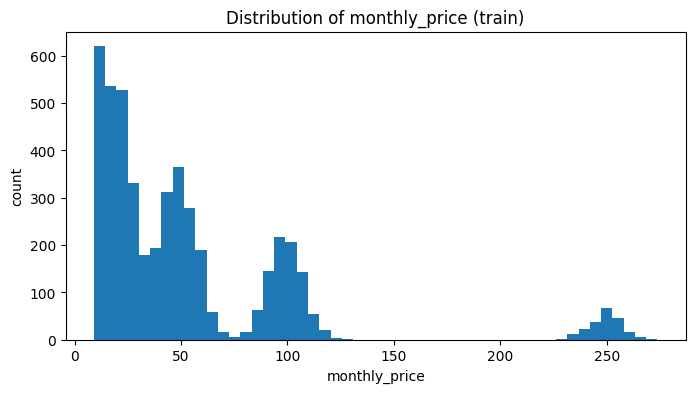

In [81]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["monthly_price"].dropna(), bins=50)
plt.xlabel("monthly_price")
plt.ylabel("count")
plt.title("Distribution of monthly_price (train)")
plt.show()

In [84]:

price_bins = [-float("inf"), 40, float("inf")]
price_labels = ["≤40", ">40"]

seg_price_40, summary_price_40 = ig_for_manual_segments(
    X=X_train,
    y=y_train,
    feature="monthly_price",
    bins=price_bins,
    labels=price_labels,
    base_entropy=base_entropy
)

seg_price_40
pd.DataFrame([summary_price_40]).round(6)

,feature,segmentation,base_entropy,weighted_entropy,information_gain,n_segments
0,monthly_price,manual,0.922811,0.918592,0.004219,3


### 3.5.5. Feature-specific threshold exploration: tenure_months
The `tenure_months` feature represents customer lifecycle progression rather than discrete behavioral or pricing tiers.

Its distribution is relatively uniform, with churn exhibiting a monotonic decline as tenure increases. As a result, sharp threshold optimization is neither necessary nor desirable.

We therefore apply lifecycle-aligned manual segmentation to reflect meaningful customer stages:

- ≤10     — early lifecycle
- 11–20   — early retention
- 21–30   — established
- 31–40   — mature
- more than >40     — long-term

This segmentation prioritizes interpretability and lifecycle insight while preserving comparable information gain to quantile-based binning.

In [85]:
X_train["tenure_months"].describe()

count    4800.000000
mean       24.606042
std        13.974674
min         1.000000
25%        12.000000
50%        25.000000
75%        37.000000
max        48.000000
Name: tenure_months, dtype: float64

In [86]:
X_train["tenure_months"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01     1.0
0.05     3.0
0.10     5.0
0.25    12.0
0.50    25.0
0.75    37.0
0.90    44.0
0.95    46.0
0.99    48.0
Name: tenure_months, dtype: float64

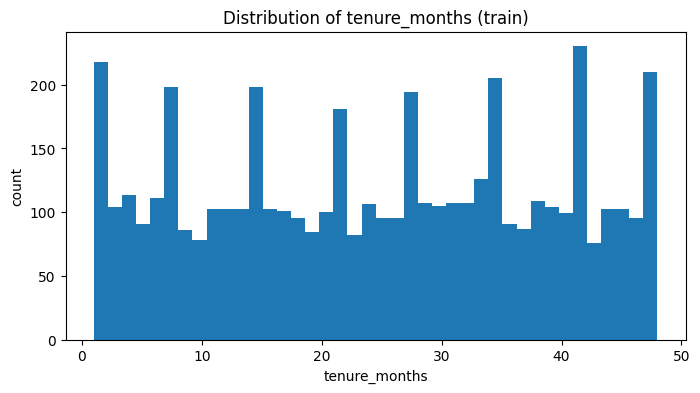

In [87]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["tenure_months"].dropna(), bins=40)
plt.xlabel("tenure_months")
plt.ylabel("count")
plt.title("Distribution of tenure_months (train)")
plt.show()

In [88]:
tenure_bins = [-float("inf"), 10, 20, 30, 40, float("inf")]
tenure_labels = ["≤10", "11–20", "21–30", "31–40", ">40"]

seg_tenure_10, summary_tenure_10 = ig_for_manual_segments(
    X=X_train,
    y=y_train,
    feature="tenure_months",
    bins=tenure_bins,
    labels=tenure_labels,
    base_entropy=base_entropy
)

seg_tenure_10
pd.DataFrame([summary_tenure_10]).round(6)

,feature,segmentation,base_entropy,weighted_entropy,information_gain,n_segments
0,tenure_months,manual,0.922811,0.8609,0.061911,5


### 3.5.6. Feature-specific threshold exploration: logins_per_week
The distribution of `logins_per_week` is approximately unimodal with moderate spread and no sharp natural breakpoints.
Quantile-based binning and simple binary splits provide limited entropy reduction.

We evaluated multiple manual segmentations and selected a three-level, behavior-driven split:

- ≤2 logins/week — low engagement
- 2–5 logins/week — regular usage
- more than 5 logins/week — high engagement

In [89]:
X_train["logins_per_week"].describe()

count    4800.000000
mean        3.529592
std         1.763961
min         0.000000
25%         2.290000
50%         3.500000
75%         4.720000
max        10.190000
Name: logins_per_week, dtype: float64

In [90]:
X_train["logins_per_week"].quantile(
    [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

0.01    0.0000
0.05    0.5795
0.10    1.2000
0.25    2.2900
0.50    3.5000
0.75    4.7200
0.90    5.8500
0.95    6.4805
0.99    7.7001
Name: logins_per_week, dtype: float64

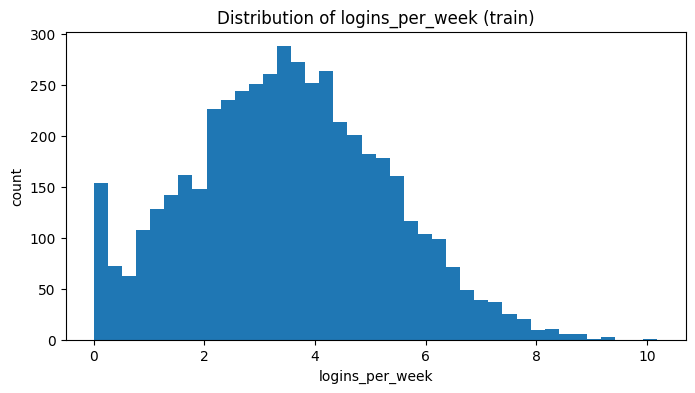

In [91]:
plt.figure(figsize=(8, 4))
plt.hist(X_train["logins_per_week"].dropna(), bins=40)
plt.xlabel("logins_per_week")
plt.ylabel("count")
plt.title("Distribution of logins_per_week (train)")
plt.show()

In [92]:
login_bins = [-float("inf"), 2, 5, float("inf")]
login_labels = ["≤2", "2–5", ">5"]

seg_logins, summary_logins = ig_for_manual_segments(
    X=X_train,
    y=y_train,
    feature="logins_per_week",
    bins=login_bins,
    labels=login_labels,
    base_entropy=base_entropy
)

seg_logins
pd.DataFrame([summary_logins]).round(6)

,feature,segmentation,base_entropy,weighted_entropy,information_gain,n_segments
0,logins_per_week,manual,0.922811,0.918112,0.0047,3
